### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [47]:
data = pd.read_csv("data/coupons.csv")
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [48]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [49]:
print("Null fields for each column:")
print(data.isnull().sum())
print("\nDuplicate entries before cleanup:", data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("\nDuplicate entries after cleanup:", data.duplicated().sum())

Null fields for each column:
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Duplicate entries before cleanup: 74

Duplicate entries after cleanup: 0


3. Decide what to do about your missing data -- drop, replace, other...

In [50]:
columns_to_clean = [
    "Bar",
    "CoffeeHouse",
    "CarryAway",
    "RestaurantLessThan20",
    "Restaurant20To50",
]

print(f"Dropping column 'Car' due to higher % of missing fields : {(data["car"].isnull().sum()/len(data)*100):.2f}%")
data_clean = data.drop(columns="car", axis=1)
print("Replacing missing fields in all columns with 'never'")
data_clean.fillna("never", inplace=True)
print("After cleanup - 'Car' column is removed and No missing field is present in any column:")
print(data_clean.isnull().sum())

Dropping column 'Car' due to higher % of missing fields : 99.14%
Replacing missing fields in all columns with 'never'
After cleanup - 'Car' column is removed and No missing field is present in any column:
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64


In [51]:
print("Final cleaned data set info:")
print(data_clean.info())

Final cleaned data set info:
<class 'pandas.core.frame.DataFrame'>
Index: 12610 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12610 non-null  object
 1   passanger             12610 non-null  object
 2   weather               12610 non-null  object
 3   temperature           12610 non-null  int64 
 4   time                  12610 non-null  object
 5   coupon                12610 non-null  object
 6   expiration            12610 non-null  object
 7   gender                12610 non-null  object
 8   age                   12610 non-null  object
 9   maritalStatus         12610 non-null  object
 10  has_children          12610 non-null  int64 
 11  education             12610 non-null  object
 12  occupation            12610 non-null  object
 13  income                12610 non-null  object
 14  Bar                   12610 non-null  object
 15  CoffeeHouse 

4. What proportion of the total observations chose to accept the coupon?



Proportion of accepted coupons: 56.76%


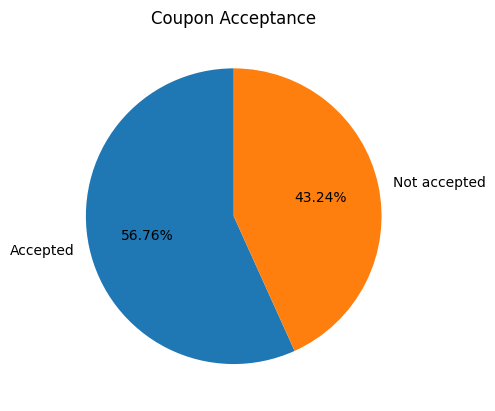

In [52]:
accepted_coupons = len(data_clean.query("Y == 1")) / len(data_clean)*100
print(f"Proportion of accepted coupons: {accepted_coupons:.2f}%")

plt.pie(
    data_clean["Y"].value_counts(),
    labels=["Accepted", "Not accepted"],
    autopct="%0.2f%%",
    startangle=90,
)
plt.title("Coupon Acceptance")
plt.show()


5. Use a bar plot to visualize the `coupon` column.

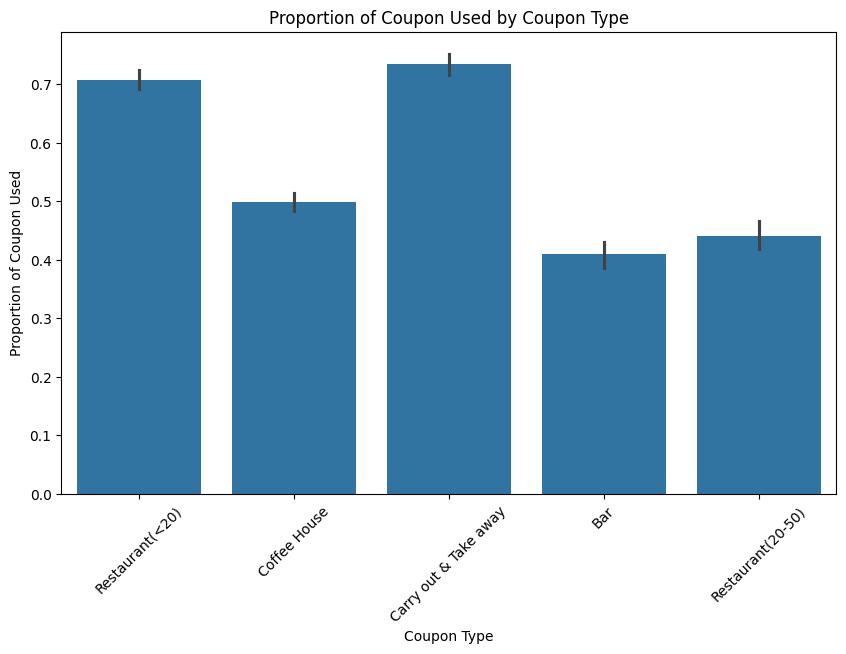

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(x="coupon", y="Y", data=data_clean)
plt.xlabel("Coupon Type")
plt.ylabel("Proportion of Coupon Used")
plt.title("Proportion of Coupon Used by Coupon Type")
plt.xticks(rotation=45)
plt.show()


6. Use a histogram to visualize the temperature column.

Unique temperature values: [55 80 30]


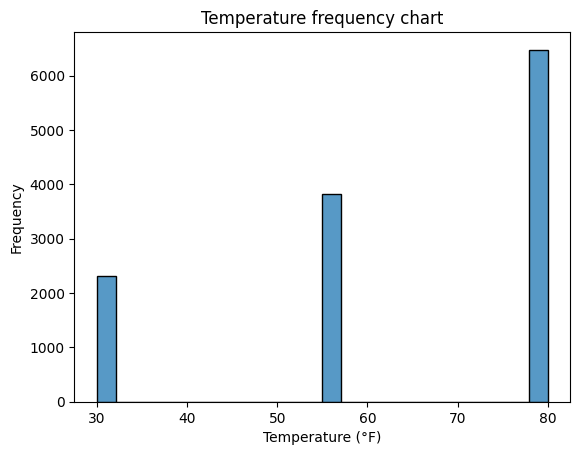

In [54]:

print("Unique temperature values:", data_clean['temperature'].unique())
sns.histplot(data_clean["temperature"])
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")
plt.title("Temperature frequency chart")
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [55]:
print("Shape of data frame:", data_clean.shape)
df_coupon_bar = data_clean.query('coupon =="Bar"')
print("Shape of bar coupon data frame:",df_coupon_bar.shape)
df_coupon_bar.head(5)


Shape of data frame: (12610, 25)
Shape of bar coupon data frame: (2010, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


Proportion of accepted bar coupons:41.00%


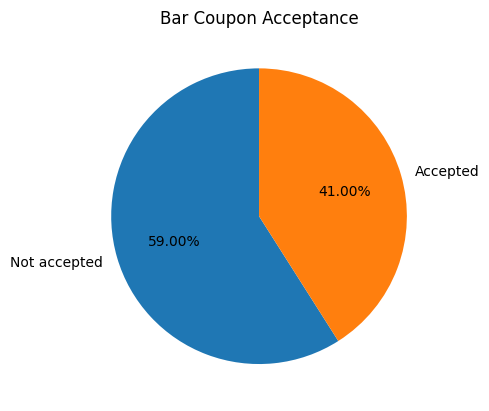

In [56]:
acceptance_bar_coupons = len(df_coupon_bar.query("Y == 1")) / len(df_coupon_bar)*100
print(f"Proportion of accepted bar coupons:{acceptance_bar_coupons:.2f}%")

plt.pie(
    df_coupon_bar["Y"].value_counts(),
    labels=["Not accepted", "Accepted"],
    autopct="%0.2f%%",
    startangle=90,
)
plt.title("Bar Coupon Acceptance")
plt.show()


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Bar values: ['never' 'less1' '1~3' 'gt8' '4~8']
Acceptance rate for Bar visits 3 or less per month: 37.05%
Acceptance rate for Bar visits more than 3 per month: 76.88%


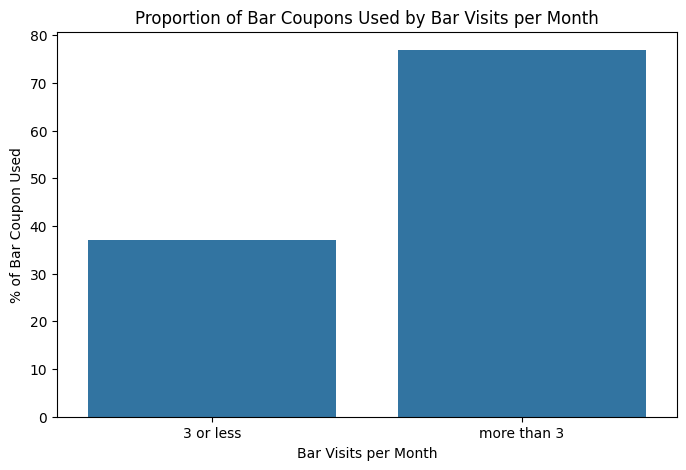

In [57]:
print("Bar values:", df_coupon_bar['Bar'].unique())
bar_3_or_less = df_coupon_bar.query('Bar.isin(["never","less1","1~3"])')
bar_more_than_3 = df_coupon_bar.query('Bar.isin(["4~8","gt8"])')


acceptance_rate_3_or_less = len(bar_3_or_less.query("Y == 1")) / len(bar_3_or_less)*100
acceptance_rate_more_than_3 = len(bar_more_than_3.query("Y == 1")) / len(bar_more_than_3)*100

print(f"Acceptance rate for Bar visits 3 or less per month: {acceptance_rate_3_or_less:.2f}%")
print(f"Acceptance rate for Bar visits more than 3 per month: {acceptance_rate_more_than_3:.2f}%")

#Plot the acceptance rates
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["3 or less", "more than 3"],
    y=[acceptance_rate_3_or_less, acceptance_rate_more_than_3],
)
plt.xlabel("Bar Visits per Month")
plt.ylabel("% of Bar Coupon Used")
plt.title("Proportion of Bar Coupons Used by Bar Visits per Month")
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Age values:  ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
Bar values:  ['never' 'less1' '1~3' 'gt8' '4~8']
Acceptance rate for Bar more than once a month and age over 25: 69.52%
Acceptance rate for Bar not more than once & age <= 25:  39.33%
Acceptance rate difference:  30.19%


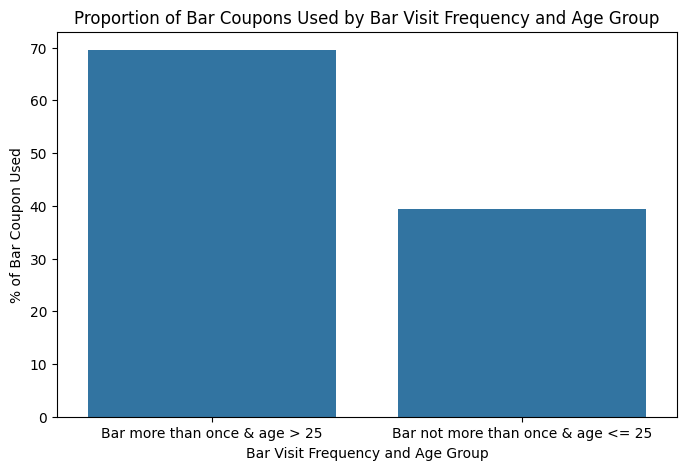

In [58]:
print("Age values: ", df_coupon_bar["age"].unique())
print("Bar values: ", df_coupon_bar["Bar"].unique())
age_below_25 = ["21", "below21"]
bar_more_than_once = ["1~3", "4~8", "gt8"]
bar_more_than_once_over_25 = df_coupon_bar.query("Bar in @bar_more_than_once & age not in @age_below_25")
bar_not_more_than_once_not_over_25 = df_coupon_bar.query("Bar not in @bar_more_than_once & age in @age_below_25")

acceptance_bar_more_than_once_over_25 = len(bar_more_than_once_over_25.query("Y == 1")) / len(bar_more_than_once_over_25)*100

acceptance_bar_not_more_than_once_not_over_25 = len( bar_not_more_than_once_not_over_25.query("Y == 1")) / len(bar_not_more_than_once_not_over_25)*100

print(f"Acceptance rate for Bar more than once a month and age over 25: {acceptance_bar_more_than_once_over_25:.2f}%")
print(f"Acceptance rate for Bar not more than once & age <= 25:  {acceptance_bar_not_more_than_once_not_over_25:.2f}%")
print(f"Acceptance rate difference:  {acceptance_bar_more_than_once_over_25 - acceptance_bar_not_more_than_once_not_over_25:.2f}%")

#Plot the acceptance rates
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["Bar more than once & age > 25", "Bar not more than once & age <= 25"],
    y=[
        acceptance_bar_more_than_once_over_25,
        acceptance_bar_not_more_than_once_not_over_25,
    ],
)
plt.xlabel("Bar Visit Frequency and Age Group")
plt.ylabel("% of Bar Coupon Used")
plt.title("Proportion of Bar Coupons Used by Bar Visit Frequency and Age Group")
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Passanger values:  ['Kid(s)' 'Alone' 'Friend(s)' 'Partner']
Acceptance rate for Bar more than once & no Kids & no FFF: 71.32%
Acceptance rate for Bar not more than once & with Kids & FFF: 33.33%


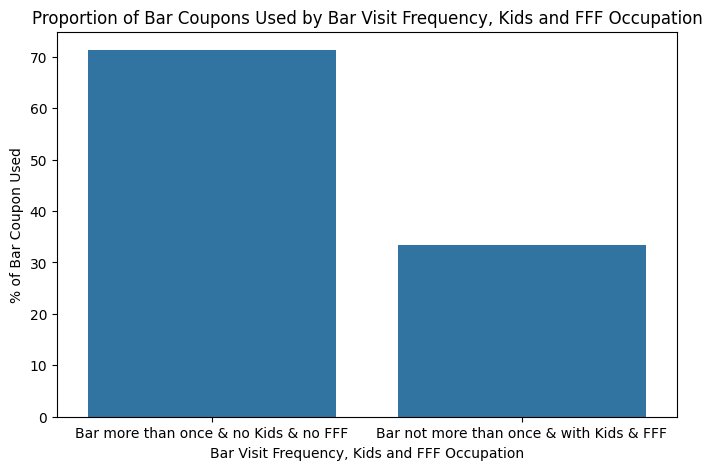

In [59]:
bar_more_than_once = ["1~3", "4~8", "gt8"]
print("Passanger values: ", df_coupon_bar["passanger"].unique())

bar_more_than_once_noKids_noFFF = df_coupon_bar.query(' Bar in @bar_more_than_once and passanger not in ["Kid(s)"] and occupation not in ["Farming Fishing & Forestry"]')
acceptance_bar_more_than_once_noKids_noFFF = len(bar_more_than_once_noKids_noFFF.query("Y == 1")) / len(bar_more_than_once_noKids_noFFF)*100
print(f"Acceptance rate for Bar more than once & no Kids & no FFF: {acceptance_bar_more_than_once_noKids_noFFF:.2f}%")

bar_less_than_once_withKids_FFF = df_coupon_bar.query(' Bar not in @bar_more_than_once and passanger in ["Kid(s)"] and occupation in ["Farming Fishing & Forestry"]')
acceptance_bar_less_than_once_withKids_FFF = len(bar_less_than_once_withKids_FFF.query("Y == 1")) / len(bar_less_than_once_withKids_FFF)*100
print(f"Acceptance rate for Bar not more than once & with Kids & FFF: {acceptance_bar_less_than_once_withKids_FFF:.2f}%")

#plot the acceptance rates
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["Bar more than once & no Kids & no FFF", "Bar not more than once & with Kids & FFF"],
    y=[
        acceptance_bar_more_than_once_noKids_noFFF,
        acceptance_bar_less_than_once_withKids_FFF,
    ],
)
plt.xlabel("Bar Visit Frequency, Kids and FFF Occupation")
plt.ylabel("% of Bar Coupon Used")
plt.title("Proportion of Bar Coupons Used by Bar Visit Frequency, Kids and FFF Occupation")
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Bar unique values:  ['never' 'less1' '1~3' 'gt8' '4~8']
Age unique values:  ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
Passanger unique values:  ['Kid(s)' 'Alone' 'Friend(s)' 'Partner']
Marital Status unique values:  ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
Income unique values:  ['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']
Acceptance rate for drivers going to bar more than once a month and passangers with no kids, not widowed: 71.32%
Acceptance rate for drivers going to bar more than once a month and age below 30: 72.17%
Acceptance rate for drivers going to cheap restaurants more than 4 times a month and income less than 50K:  45.35%


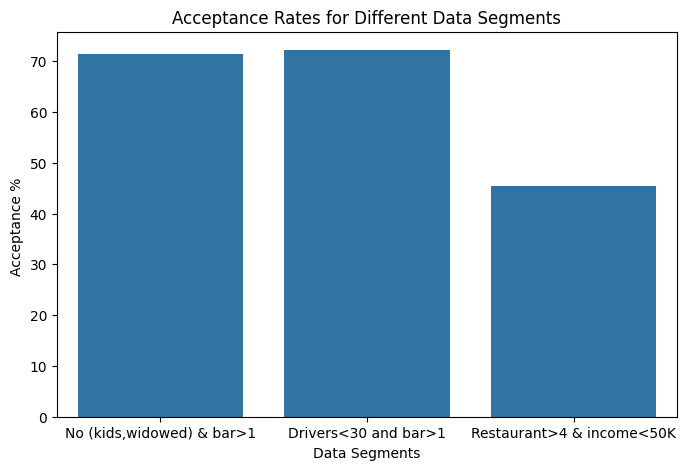

In [60]:
print("Bar unique values: ", df_coupon_bar["Bar"].unique())
print("Age unique values: ", df_coupon_bar["age"].unique())
print("Passanger unique values: ", df_coupon_bar["passanger"].unique())
print("Marital Status unique values: ", df_coupon_bar["maritalStatus"].unique())
print("Income unique values: ", df_coupon_bar["income"].unique())


bar_more_than_once = df_coupon_bar.query('Bar.isin(["1~3", "4~8","gt8"])')
data6_1 = bar_more_than_once.query('passanger not in ["Kid(s)"] & maritalStatus not in ["widowed"]')
acceptance_data6_1 = len(data6_1.query("Y == 1")) / len(data6_1)*100
print(f"Acceptance rate for drivers going to bar more than once a month and passangers with no kids, not widowed: {acceptance_data6_1:.2f}%")
      
data6_2 = bar_more_than_once.query('age in ["below21","21","26"]')
acceptance_data6_2 = len(data6_2.query("Y == 1")) / len(data6_2)*100
print(f"Acceptance rate for drivers going to bar more than once a month and age below 30: {acceptance_data6_2:.2f}%")

data6_3 = df_coupon_bar.query('RestaurantLessThan20 in ["4~8","gt8"] & income in ["Less than $12500","$12500 - $24999","$25000 - $37499","$37500 - $49999"]')
acceptance_data6_3 = len(data6_3.query("Y == 1")) / len(data6_3)*100
print(f"Acceptance rate for drivers going to cheap restaurants more than 4 times a month and income less than 50K:  {acceptance_data6_3:.2f}%")

#Plot the acceptance rates
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["No (kids,widowed) & bar>1", "Drivers<30 and bar>1", "Restaurant>4 & income<50K"],
    y=[acceptance_data6_1, acceptance_data6_2, acceptance_data6_3],
)
plt.xlabel("Data Segments")
plt.ylabel("Acceptance % ")
plt.title("Acceptance Rates for Different Data Segments")
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [61]:
#Observations about drivers who accepted the bar coupons:
print("Observations about drivers who accepted the bar coupons:")
print(f"1. Drivers who go to bars more than three times a month have the highest acceptance rate of {acceptance_rate_more_than_3:.2f}% compared to others.")
print(f"2. Younger drivers (age <= 25) who visit bars less than once a month have a significantly lower acceptance rate of {acceptance_bar_not_more_than_once_not_over_25:.2f}% compared to older frequent visitors.")
print(f"3. Drivers with lowest acceptance rate ({acceptance_bar_less_than_once_withKids_FFF:.2f}%) are those who visit bars less than once a month, have kids, and work in Farming Fishing & Forestry occupations.")
print(f"4. Drivers with lower income (below $50K) who frequently dine at inexpensive restaurants also exhibit a notable acceptance rate of {acceptance_data6_3:.2f}%.")
print("These insights are helpful in targeting specific demographics for bar coupon promotions.")






Observations about drivers who accepted the bar coupons:
1. Drivers who go to bars more than three times a month have the highest acceptance rate of 76.88% compared to others.
2. Younger drivers (age <= 25) who visit bars less than once a month have a significantly lower acceptance rate of 39.33% compared to older frequent visitors.
3. Drivers with lowest acceptance rate (33.33%) are those who visit bars less than once a month, have kids, and work in Farming Fishing & Forestry occupations.
4. Drivers with lower income (below $50K) who frequently dine at inexpensive restaurants also exhibit a notable acceptance rate of 45.35%.
These insights are helpful in targeting specific demographics for bar coupon promotions.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [62]:
print("Available coupon types:", data_clean['coupon'].unique())
print("####----------Selecting Coffee House coupons for futher analysis------------#####")
df_coffeehouse = data_clean.query('coupon =="Coffee House"')
print("First 5 rows of Coffee House coupon data frame:")
df_coffeehouse.head(5)

Available coupon types: ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
####----------Selecting Coffee House coupons for futher analysis------------#####
First 5 rows of Coffee House coupon data frame:


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,0


In [63]:
print("Zero duplicate entries in Coffee House coupon data frame:", df_coffeehouse.duplicated().sum())
print("No Null fields present in Coffee House coupon data frame:")
print(df_coffeehouse.isnull().sum())
print("Therefore coffee house data frame has no missing or duplicate entries.")
print("Shape of coffee house coupon data frame:", df_coffeehouse.shape)


Zero duplicate entries in Coffee House coupon data frame: 0
No Null fields present in Coffee House coupon data frame:
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64
Therefore coffee house data frame has no missing or duplicate entries.
Shape of coffee house coupon data frame: (3989, 25)


Percentage of accepted coffee house coupons:49.86%


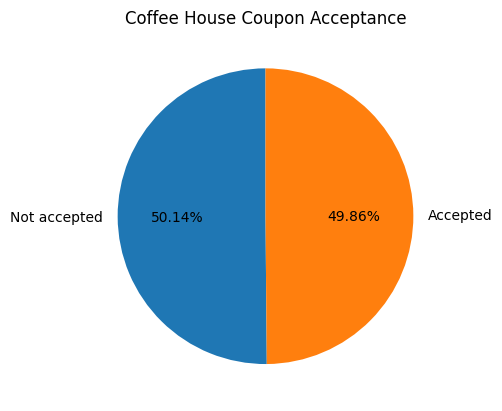

In [64]:
acceptance_coffeehouse_coupons = len(df_coffeehouse.query("Y == 1")) / len(df_coffeehouse)*100
print(f"Percentage of accepted coffee house coupons:{acceptance_coffeehouse_coupons:.2f}%")
plt.pie(
    df_coffeehouse["Y"].value_counts(),
    labels=["Not accepted", "Accepted"],
    autopct="%0.2f%%",
    startangle=90,
)
plt.title("Coffee House Coupon Acceptance")
plt.show()

CoffeeHouse unique values:  ['never' 'less1' '4~8' '1~3' 'gt8']
Age unique values:  ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
Acceptance rate for CoffeeHouse more than once & age over 25: 63.81%
Acceptance rate for CoffeeHouse not more than once & age <= 25: 35.65%


<Axes: >

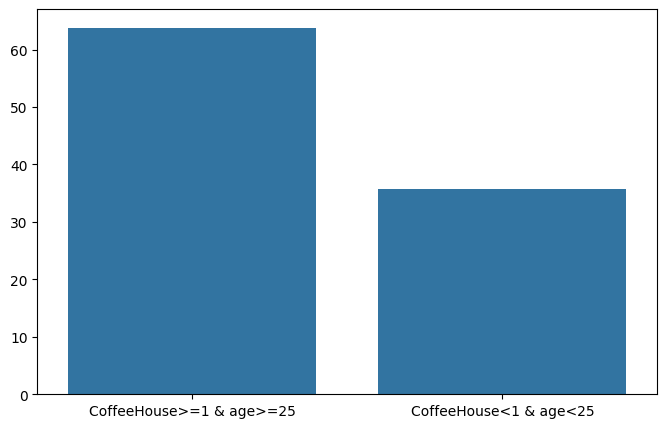

In [65]:
#Coffee Coupon acceptance based on CoffeeHouse visit frequency and age
print("CoffeeHouse unique values: ", df_coffeehouse["CoffeeHouse"].unique())
print("Age unique values: ", df_coffeehouse["age"].unique())
coffeehouse_more_than_once = ["1~3", "4~8", "gt8"]
age_below_25 = ["21", "below21"]
coffeehouse_more_than_once_over_25 = df_coffeehouse.query("CoffeeHouse in @coffeehouse_more_than_once & age not in @age_below_25")
acceptance_coffeehouse_more_than_once_over_25 = len(coffeehouse_more_than_once_over_25.query("Y == 1")) / len(coffeehouse_more_than_once_over_25)*100    
print(f"Acceptance rate for CoffeeHouse more than once & age over 25: {acceptance_coffeehouse_more_than_once_over_25:.2f}%")

coffeehouse_not_more_than_once_not_over_25 = df_coffeehouse.query("CoffeeHouse not in @coffeehouse_more_than_once & age in @age_below_25")
acceptance_coffeehouse_not_more_than_once_not_over_25 = len(coffeehouse_not_more_than_once_not_over_25.query("Y == 1")) / len(coffeehouse_not_more_than_once_not_over_25)*100
print(f"Acceptance rate for CoffeeHouse not more than once & age <= 25: {acceptance_coffeehouse_not_more_than_once_not_over_25:.2f}%")

#Plot the acceptance rates
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["CoffeeHouse>=1 & age>=25", "CoffeeHouse<1 & age<25"],
    y=[
        acceptance_coffeehouse_more_than_once_over_25,
        acceptance_coffeehouse_not_more_than_once_not_over_25,
    ],
)


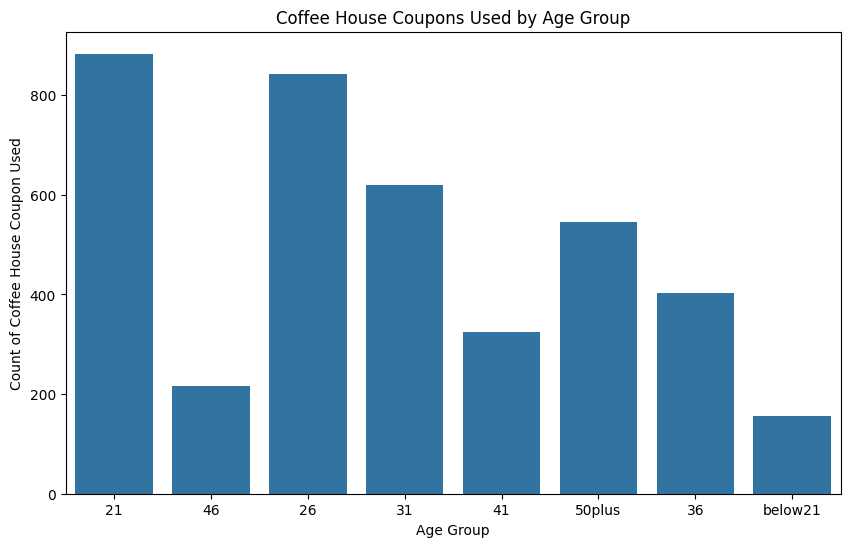

In [66]:
#Accepted coffee house coupons by age group
plt.figure(figsize=(10, 6))
accepted_coffee_house=df_coffeehouse[df_coffeehouse['Y']==True]
sns.countplot(x='age',order=accepted_coffee_house['age'].unique(), data=df_coffeehouse)
plt.xlabel("Age Group")
plt.ylabel("Count of Coffee House Coupon Used")
plt.title("Coffee House Coupons Used by Age Group")
plt.show()


In [67]:
#Conclusion:
print("Conclusion:")
print(f"1. Coffee House coupons are accepted at a higher rate ({acceptance_coffeehouse_coupons:.2f}%) than compared to bar coupons ({acceptance_bar_coupons:.2f}%).")
print(f"2. Frequent coffee house visitors over 25 years old show a higher acceptance rate ({acceptance_coffeehouse_more_than_once_over_25:.2f}%) compared to infrequent visitors 25 or younger.")
print("3. Age group 21 has the largest acceptor of coffee house coupons, indicating that younger adults are more inclined to use coffehouse coupons.")

Conclusion:
1. Coffee House coupons are accepted at a higher rate (49.86%) than compared to bar coupons (41.00%).
2. Frequent coffee house visitors over 25 years old show a higher acceptance rate (63.81%) compared to infrequent visitors 25 or younger.
3. Age group 21 has the largest acceptor of coffee house coupons, indicating that younger adults are more inclined to use coffehouse coupons.
